# Evolutionary Strategies for the 2D Rastrigin Function

**Homework 3 — Spring 2026**

Apply (µ,λ)-ES with the 1/5 success rule to minimize the 2D Rastrigin function.
Global minimum at (0, 0) with f(0, 0) = 0.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time, os
from scipy.stats import ttest_ind, f_oneway

# Step 1: Problem Definition — 2D Rastrigin Function

$$f(x_1, x_2) = 20 + (x_1^2 - 10\cos(2\pi x_1)) + (x_2^2 - 10\cos(2\pi x_2))$$

- Variable range: [-5.12, 5.12]
- Global minimum: f(0, 0) = 0

In [2]:
def rastrigin(x):
    """2D Rastrigin function. x is array of shape (2,) or (n, 2)."""
    x = np.asarray(x)
    if x.ndim == 1:
        return 20 + (x[0]**2 - 10*np.cos(2*np.pi*x[0])) + (x[1]**2 - 10*np.cos(2*np.pi*x[1]))
    else:
        return 20 + np.sum(x**2 - 10*np.cos(2*np.pi*x), axis=1)

# Bounds
LOWER, UPPER = -5.12, 5.12
N_VARS = 2

# Sanity check
print(f"f(0, 0)     = {rastrigin([0, 0]):.6f}  (should be 0)")
print(f"f(1, 1)     = {rastrigin([1, 1]):.6f}")
print(f"f(5.12,5.12)= {rastrigin([5.12, 5.12]):.6f}")

f(0, 0)     = 0.000000  (should be 0)
f(1, 1)     = 2.000000
f(5.12,5.12)= 57.849427


## Rastrigin Surface Plot

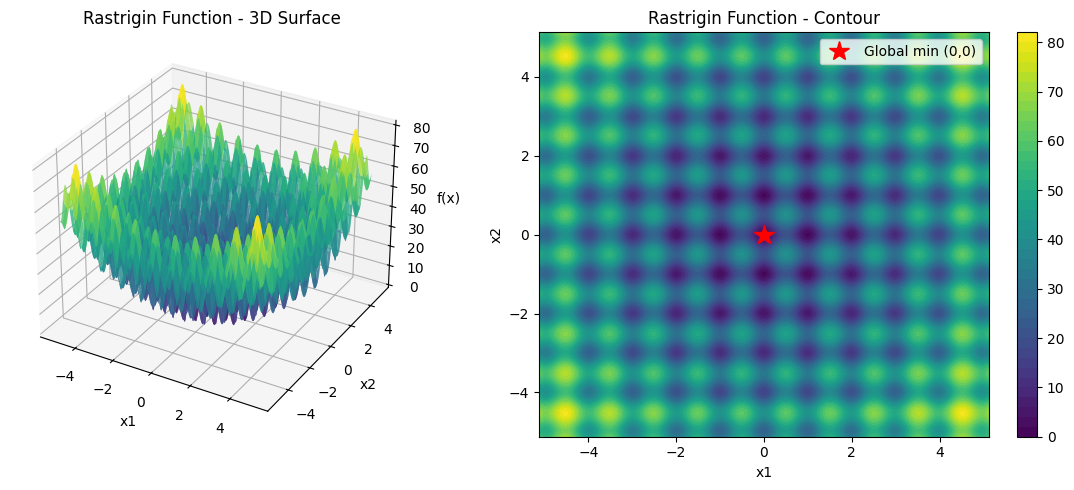

In [3]:
x1 = np.linspace(LOWER, UPPER, 200)
x2 = np.linspace(LOWER, UPPER, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = 20 + (X1**2 - 10*np.cos(2*np.pi*X1)) + (X2**2 - 10*np.cos(2*np.pi*X2))

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('f(x)')
ax1.set_title('Rastrigin Function - 3D Surface')

ax2 = fig.add_subplot(122)
c = ax2.contourf(X1, X2, Z, levels=50, cmap='viridis')
plt.colorbar(c, ax=ax2)
ax2.plot(0, 0, 'r*', markersize=15, label='Global min (0,0)')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2')
ax2.set_title('Rastrigin Function - Contour')
ax2.legend()

plt.tight_layout()
plt.savefig('rastrigin_surface.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 2: ES Core Functions

All five ES variants are implemented as a single configurable function.

- **individual_sigma**: Each variable gets its own step size
- **sigma_recombination**: Global intermediate recombination on sigma
- **variable_recombination**: Dual discrete recombination on x

In [4]:
def run_es(mu, lam, max_gen=500, seed=42,
           individual_sigma=False,
           sigma_recombination=False,
           variable_recombination=False,
           sigma_init=1.0, check_interval=10, c_factor=0.82):
    """
    (mu, lam)-ES for the 2D Rastrigin function.

    Parameters
    ----------
    mu              : number of parents selected each generation
    lam             : number of offspring generated each generation
    max_gen         : maximum generations (stopping criterion)
    seed            : random seed
    individual_sigma: if True, each variable has its own sigma
    sigma_recombination : if True, apply global intermediate recombination on sigma
    variable_recombination : if True, apply dual discrete recombination on x
    sigma_init      : initial standard deviation
    check_interval  : how often to check the 1/5 rule
    c_factor        : damping factor for the 1/5 rule

    Returns
    -------
    best_x, best_cost, history
    """
    np.random.seed(seed)

    n = N_VARS  # 2

    # ---------- INITIALISE POPULATION ----------
    if individual_sigma:
        sigmas = np.full((mu, n), sigma_init)
    else:
        sigmas = np.full((mu, 1), sigma_init)

    # Random initial parent population within bounds
    pop = np.random.uniform(LOWER, UPPER, size=(mu, n))
    fitness = rastrigin(pop)

    best_idx = np.argmin(fitness)
    best_x = pop[best_idx].copy()
    best_cost = fitness[best_idx]
    history = []

    successes = 0
    total_offspring = 0

    for gen in range(max_gen):
        history.append(best_cost)

        # ---------- GENERATE LAMBDA OFFSPRING ----------
        offspring_x = np.empty((lam, n))
        if individual_sigma:
            offspring_sigma = np.empty((lam, n))
        else:
            offspring_sigma = np.empty((lam, 1))

        for i in range(lam):
            # Pick a random parent
            p_idx = np.random.randint(mu)
            parent_x = pop[p_idx]
            parent_sigma = sigmas[p_idx]

            # Mutate: x_new = x + sigma * N(0,1)
            child_sigma = parent_sigma.copy()
            if individual_sigma:
                child_x = parent_x + child_sigma * np.random.randn(n)
            else:
                child_x = parent_x + child_sigma[0] * np.random.randn(n)

            # Clip to bounds
            child_x = np.clip(child_x, LOWER, UPPER)

            offspring_x[i] = child_x
            offspring_sigma[i] = child_sigma

        offspring_fitness = rastrigin(offspring_x)

        # Count successes (offspring better than median parent cost)
        parent_median_cost = np.median(fitness)
        successes += int(np.sum(offspring_fitness < parent_median_cost))
        total_offspring += lam

        # ---------- 1/5 SUCCESS RULE (every check_interval generations) ----------
        if (gen + 1) % check_interval == 0 and total_offspring > 0:
            success_rate = successes / total_offspring
            if success_rate > 0.2:
                offspring_sigma /= c_factor   # increase sigma (divide by c < 1)
            elif success_rate < 0.2:
                offspring_sigma *= c_factor   # decrease sigma (multiply by c < 1)
            # if == 0.2, keep sigma unchanged
            successes = 0
            total_offspring = 0

        # ---------- RECOMBINATION (if enabled) ----------
        # Sigma recombination: global intermediate recombination on sigma
        if sigma_recombination and lam >= 2:
            new_sigma = np.empty_like(offspring_sigma)
            for i in range(lam):
                r1, r2 = np.random.choice(lam, 2, replace=False)
                new_sigma[i] = (offspring_sigma[r1] + offspring_sigma[r2]) / 2.0
            offspring_sigma = new_sigma

        # Variable recombination: dual discrete recombination on x
        if variable_recombination and lam >= 2:
            new_x = np.empty_like(offspring_x)
            for i in range(lam):
                r1, r2 = np.random.choice(lam, 2, replace=False)
                mask = np.random.randint(0, 2, size=n)
                new_x[i] = np.where(mask, offspring_x[r1], offspring_x[r2])
            new_x = np.clip(new_x, LOWER, UPPER)
            offspring_x = new_x
            offspring_fitness = rastrigin(offspring_x)

        # ---------- (mu, lambda) SELECTION ----------
        sorted_idx = np.argsort(offspring_fitness)[:mu]
        pop = offspring_x[sorted_idx]
        sigmas = offspring_sigma[sorted_idx]
        fitness = offspring_fitness[sorted_idx]

        # Track global best
        gen_best_idx = np.argmin(fitness)
        if fitness[gen_best_idx] < best_cost:
            best_cost = fitness[gen_best_idx]
            best_x = pop[gen_best_idx].copy()

    return best_x, best_cost, history

# Step 3: Single Run Test (Basic ES)

In [5]:
best_x, best_cost, history = run_es(mu=15, lam=100, max_gen=500, seed=42,
                                    individual_sigma=False,
                                    sigma_recombination=False,
                                    variable_recombination=False)

print(f"Best solution found: x = ({best_x[0]:.6f}, {best_x[1]:.6f})")
print(f"Best cost:           f(x) = {best_cost:.6f}")
print(f"Global optimum:      f(0,0) = 0.0")
print(f"Gap from optimal:    {best_cost:.6f}")

Best solution found: x = (0.002739, -0.036892)
Best cost:           f(x) = 0.270299
Global optimum:      f(0,0) = 0.0
Gap from optimal:    0.270299


## Single Run Convergence Plot

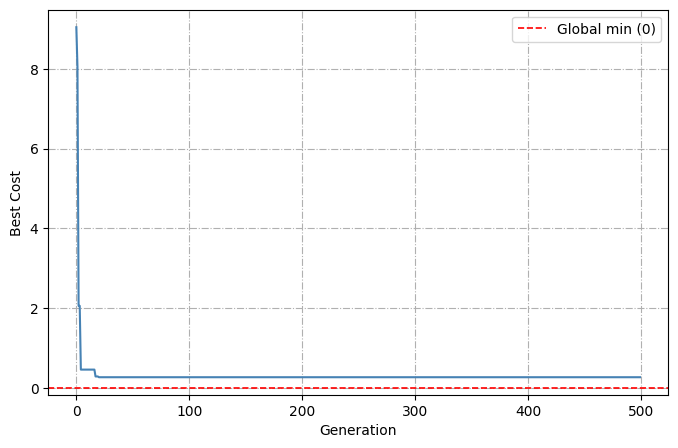

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(history, color='steelblue', linewidth=1.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Global min (0)')
plt.xlabel("Generation")
plt.ylabel("Best Cost")
#plt.yscale('log')
#plt.title("ES Convergence on 2D Rastrigin Function")
plt.legend()
plt.grid(True, linestyle='-.')

os.makedirs('ES_Results', exist_ok=True)
plt.savefig('ES_Results/single_run_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## Solution on Contour Plot

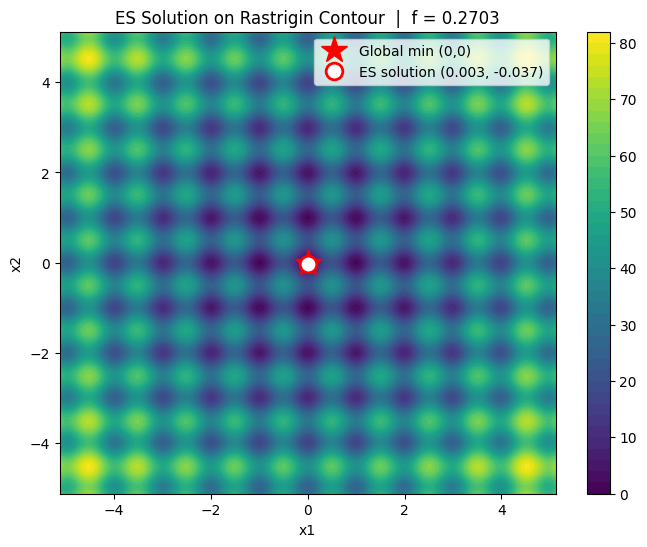

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
c = ax.contourf(X1, X2, Z, levels=50, cmap='viridis')
plt.colorbar(c, ax=ax)
ax.plot(0, 0, 'r*', markersize=20, label='Global min (0,0)', zorder=5)
ax.plot(best_x[0], best_x[1], 'wo', markersize=12, markeredgecolor='red',
        markeredgewidth=2, label=f'ES solution ({best_x[0]:.3f}, {best_x[1]:.3f})', zorder=5)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title(f'ES Solution on Rastrigin Contour  |  f = {best_cost:.4f}')
ax.legend(loc='upper right')
plt.savefig('ES_Results/solution_contour.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 4: Experiment A: Basic ES with 5 Seeds (5 runs)

Single shared sigma, 1/5 rule, no recombination. Fixed mu=15, lam=100.

In [8]:
seeds = [1, 2, 3, 4, 5]
results_all = []
run_id = 0

# -- Experiment A: Basic ES, 5 seeds --
print("=" * 60)
print("EXPERIMENT A: Basic ES - single sigma, 1/5 rule, no recombination")
print("=" * 60)

for seed in seeds:
    run_id += 1
    t0 = time.perf_counter()
    bx, bc, hist = run_es(mu=15, lam=100, max_gen=500, seed=seed,
                          individual_sigma=False,
                          sigma_recombination=False,
                          variable_recombination=False)
    runtime = time.perf_counter() - t0

    results_all.append({
        "run_id": run_id, "experiment": "A_basic",
        "seed": seed, "mu": 15, "lam": 100,
        "mu_lam_ratio": "15:100",
        "individual_sigma": False, "sigma_recomb": False, "var_recomb": False,
        "best_x1": bx[0], "best_x2": bx[1],
        "best_cost": bc, "generations": len(hist),
        "history": hist, "runtime_s": runtime
    })
    print(f"  Seed {seed}: f = {bc:.6f}  at ({bx[0]:.4f}, {bx[1]:.4f})  [{runtime:.2f}s]")

print(f"\nExperiment A complete: {len([r for r in results_all if r['experiment']=='A_basic'])} runs")

EXPERIMENT A: Basic ES - single sigma, 1/5 rule, no recombination
  Seed 1: f = 0.000000  at (0.0000, -0.0000)  [0.13s]
  Seed 2: f = 0.000000  at (0.0000, 0.0000)  [0.13s]
  Seed 3: f = 0.226909  at (0.0258, -0.0219)  [0.13s]
  Seed 4: f = 0.000000  at (-0.0000, 0.0000)  [0.13s]
  Seed 5: f = 0.000000  at (-0.0000, 0.0000)  [0.13s]

Experiment A complete: 5 runs


# Step 5: Experiment B: mu:lam Ratio Sweep (15 runs)

Three different mu:lam ratios x 5 seeds = 15 runs.
Single shared sigma, 1/5 rule, no recombination.

In [9]:
mu_lam_configs = [
    (5,  35,  "5:35"),
    (15, 100, "15:100"),
    (30, 200, "30:200"),
]

print("=" * 60)
print("EXPERIMENT B: mu:lam ratio sweep - 3 ratios x 5 seeds")
print("=" * 60)

for mu_val, lam_val, ratio_label in mu_lam_configs:
    print(f"\n  Ratio mu:lam = {ratio_label}")
    for seed in seeds:
        run_id += 1
        t0 = time.perf_counter()
        bx, bc, hist = run_es(mu=mu_val, lam=lam_val, max_gen=500, seed=seed,
                              individual_sigma=False,
                              sigma_recombination=False,
                              variable_recombination=False)
        runtime = time.perf_counter() - t0

        results_all.append({
            "run_id": run_id, "experiment": "B_ratio",
            "seed": seed, "mu": mu_val, "lam": lam_val,
            "mu_lam_ratio": ratio_label,
            "individual_sigma": False, "sigma_recomb": False, "var_recomb": False,
            "best_x1": bx[0], "best_x2": bx[1],
            "best_cost": bc, "generations": len(hist),
            "history": hist, "runtime_s": runtime
        })
        print(f"    Seed {seed}: f = {bc:.6f}  at ({bx[0]:.4f}, {bx[1]:.4f})")

# Find best ratio
df_b = pd.DataFrame([r for r in results_all if r['experiment'] == 'B_ratio'])
best_ratio_row = df_b.groupby('mu_lam_ratio')['best_cost'].mean().idxmin()
best_mu = int(df_b[df_b['mu_lam_ratio'] == best_ratio_row].iloc[0]['mu'])
best_lam = int(df_b[df_b['mu_lam_ratio'] == best_ratio_row].iloc[0]['lam'])
print(f"\n>>> Best mu:lam ratio: {best_ratio_row} (mean cost = {df_b.groupby('mu_lam_ratio')['best_cost'].mean().min():.6f})")
print(f"    Using mu={best_mu}, lam={best_lam} for subsequent experiments.")

EXPERIMENT B: mu:lam ratio sweep - 3 ratios x 5 seeds

  Ratio mu:lam = 5:35
    Seed 1: f = 0.000000  at (0.0000, 0.0000)
    Seed 2: f = 0.058149  at (0.0127, 0.0115)
    Seed 3: f = 0.212475  at (-0.0091, -0.0315)
    Seed 4: f = 0.000000  at (0.0000, 0.0000)
    Seed 5: f = 0.041357  at (-0.0143, -0.0020)

  Ratio mu:lam = 15:100
    Seed 1: f = 0.000000  at (0.0000, -0.0000)
    Seed 2: f = 0.000000  at (0.0000, 0.0000)
    Seed 3: f = 0.226909  at (0.0258, -0.0219)
    Seed 4: f = 0.000000  at (-0.0000, 0.0000)
    Seed 5: f = 0.000000  at (-0.0000, 0.0000)

  Ratio mu:lam = 30:200
    Seed 1: f = 0.000000  at (0.0000, 0.0000)
    Seed 2: f = 0.000000  at (-0.0000, -0.0000)
    Seed 3: f = 0.000000  at (-0.0000, 0.0000)
    Seed 4: f = 0.000000  at (-0.0000, -0.0000)
    Seed 5: f = 0.000000  at (0.0000, 0.0000)

>>> Best mu:lam ratio: 30:200 (mean cost = 0.000000)
    Using mu=30, lam=200 for subsequent experiments.


# Step 6: Experiment C: Individual sigma per Variable (5 runs)

Using the best mu:lam ratio from Experiment B. Each variable gets its own sigma, adapted with the 1/5 rule.

In [10]:
print("=" * 60)
print(f"EXPERIMENT C: Individual sigma - mu={best_mu}, lam={best_lam}")
print("=" * 60)

for seed in seeds:
    run_id += 1
    t0 = time.perf_counter()
    bx, bc, hist = run_es(mu=best_mu, lam=best_lam, max_gen=500, seed=seed,
                          individual_sigma=True,
                          sigma_recombination=False,
                          variable_recombination=False)
    runtime = time.perf_counter() - t0

    results_all.append({
        "run_id": run_id, "experiment": "C_indiv_sigma",
        "seed": seed, "mu": best_mu, "lam": best_lam,
        "mu_lam_ratio": f"{best_mu}:{best_lam}",
        "individual_sigma": True, "sigma_recomb": False, "var_recomb": False,
        "best_x1": bx[0], "best_x2": bx[1],
        "best_cost": bc, "generations": len(hist),
        "history": hist, "runtime_s": runtime
    })
    print(f"  Seed {seed}: f = {bc:.6f}  at ({bx[0]:.4f}, {bx[1]:.4f})")

print(f"\nExperiment C complete: 5 runs")

EXPERIMENT C: Individual sigma - mu=30, lam=200
  Seed 1: f = 0.000000  at (0.0000, 0.0000)
  Seed 2: f = 0.000000  at (-0.0000, -0.0000)
  Seed 3: f = 0.000000  at (-0.0000, 0.0000)
  Seed 4: f = 0.000000  at (-0.0000, -0.0000)
  Seed 5: f = 0.000000  at (0.0000, 0.0000)

Experiment C complete: 5 runs


# Step 7: Experiment D: Global Intermediate Recombination on sigma (5 runs)

Using the best ES from previous experiments. Individual sigma + global intermediate recombination on sigma.

**Process:** First apply 1/5 rule (if its time), then recombine sigma.

In [11]:
print("=" * 60)
print(f"EXPERIMENT D: sigma recombination - mu={best_mu}, lam={best_lam}")
print("=" * 60)

for seed in seeds:
    run_id += 1
    t0 = time.perf_counter()
    bx, bc, hist = run_es(mu=best_mu, lam=best_lam, max_gen=500, seed=seed,
                          individual_sigma=True,
                          sigma_recombination=True,
                          variable_recombination=False)
    runtime = time.perf_counter() - t0

    results_all.append({
        "run_id": run_id, "experiment": "D_sigma_recomb",
        "seed": seed, "mu": best_mu, "lam": best_lam,
        "mu_lam_ratio": f"{best_mu}:{best_lam}",
        "individual_sigma": True, "sigma_recomb": True, "var_recomb": False,
        "best_x1": bx[0], "best_x2": bx[1],
        "best_cost": bc, "generations": len(hist),
        "history": hist, "runtime_s": runtime
    })
    print(f"  Seed {seed}: f = {bc:.6f}  at ({bx[0]:.4f}, {bx[1]:.4f})")

print(f"\nExperiment D complete: 5 runs")

EXPERIMENT D: sigma recombination - mu=30, lam=200
  Seed 1: f = 0.000000  at (-0.0000, -0.0000)
  Seed 2: f = 0.000000  at (0.0000, 0.0000)
  Seed 3: f = 0.000000  at (-0.0000, 0.0000)
  Seed 4: f = 0.000000  at (-0.0000, -0.0000)
  Seed 5: f = 0.000000  at (-0.0000, 0.0000)

Experiment D complete: 5 runs


# Step 8: Experiment E — Dual Discrete Recombination on x (5 runs)

Using the best ES from all previous experiments. Add dual discrete recombination on decision variables along with individual sigma (from Experiment C).

**Process:** First create the next generation using the usual approach, then perform recombination.

In [12]:
print("=" * 60)
print(f"EXPERIMENT E: Dual discrete recombination on x - mu={best_mu}, lam={best_lam}")
print("=" * 60)

for seed in seeds:
    run_id += 1
    t0 = time.perf_counter()
    bx, bc, hist = run_es(mu=best_mu, lam=best_lam, max_gen=500, seed=seed,
                          individual_sigma=True,
                          sigma_recombination=False,
                          variable_recombination=True)
    runtime = time.perf_counter() - t0

    results_all.append({
        "run_id": run_id, "experiment": "E_var_recomb",
        "seed": seed, "mu": best_mu, "lam": best_lam,
        "mu_lam_ratio": f"{best_mu}:{best_lam}",
        "individual_sigma": True, "sigma_recomb": False, "var_recomb": True,
        "best_x1": bx[0], "best_x2": bx[1],
        "best_cost": bc, "generations": len(hist),
        "history": hist, "runtime_s": runtime
    })
    print(f"  Seed {seed}: f = {bc:.6f}  at ({bx[0]:.4f}, {bx[1]:.4f})")

print(f"\nExperiment E complete: 5 runs")
print(f"\n{'='*60}")
print(f"TOTAL RUNS: {run_id}  (expected: 35)")
print(f"{'='*60}")

EXPERIMENT E: Dual discrete recombination on x - mu=30, lam=200
  Seed 1: f = 0.000000  at (0.0000, 0.0000)
  Seed 2: f = 0.000000  at (0.0000, -0.0000)
  Seed 3: f = 0.000000  at (-0.0000, -0.0000)
  Seed 4: f = 0.000000  at (0.0000, 0.0000)
  Seed 5: f = 0.000000  at (-0.0000, -0.0000)

Experiment E complete: 5 runs

TOTAL RUNS: 35  (expected: 35)


# Step 9: Results Summary & Statistical Analysis

In [13]:
results_df = pd.DataFrame(results_all)
save_cols = [c for c in results_df.columns if c != 'history']
os.makedirs('ES_Results', exist_ok=True)
results_df[save_cols].to_csv('ES_Results/all_35_runs.csv', index=False)

print(f"Total runs: {len(results_df)}")
print(results_df[['run_id','experiment','seed','mu','lam','mu_lam_ratio',
                   'best_x1','best_x2','best_cost','runtime_s']].to_string(index=False))

Total runs: 35
 run_id     experiment  seed  mu  lam mu_lam_ratio       best_x1       best_x2    best_cost  runtime_s
      1        A_basic     1  15  100       15:100  1.398745e-06 -1.425178e-06 7.911112e-10   0.133338
      2        A_basic     2  15  100       15:100  1.818018e-06  1.070620e-06 8.831265e-10   0.133421
      3        A_basic     3  15  100       15:100  2.579508e-02 -2.192168e-02 2.269095e-01   0.129757
      4        A_basic     4  15  100       15:100 -5.374593e-07  7.334546e-07 1.640359e-10   0.131303
      5        A_basic     5  15  100       15:100 -3.990334e-08  2.012690e-06 8.039862e-10   0.128681
      6        B_ratio     1   5   35         5:35  4.430384e-06  5.894955e-07 3.963045e-09   0.051296
      7        B_ratio     2   5   35         5:35  1.265340e-02  1.153840e-02 5.814900e-02   0.049734
      8        B_ratio     3   5   35         5:35 -9.096428e-03 -3.148773e-02 2.124751e-01   0.049382
      9        B_ratio     4   5   35         5:35  3.0909

## 9.1 Boxplots: Best Cost by Experiment

/var/folders/w2/8rhf6prd1mv2_x48l625r7nw0000gn/T/ipykernel_87119/2002157956.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


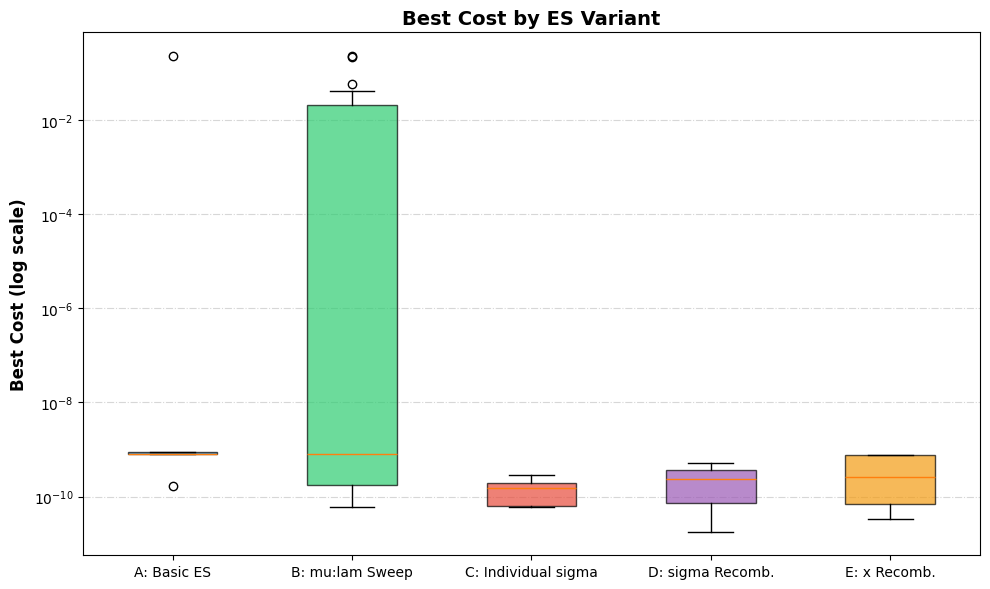

In [47]:
exp_labels = {
    'A_basic': 'A: Basic ES',
    'B_ratio': 'B: mu:lam Sweep',
    'C_indiv_sigma': 'C: Individual sigma',
    'D_sigma_recomb': 'D: sigma Recomb.',
    'E_var_recomb': 'E: x Recomb.'
}

fig, ax = plt.subplots(figsize=(10, 6))
experiments = ['A_basic', 'B_ratio', 'C_indiv_sigma', 'D_sigma_recomb', 'E_var_recomb']
data = [results_df[results_df['experiment'] == e]['best_cost'].values for e in experiments]
labels = [exp_labels[e] for e in experiments]

bp = ax.boxplot(data, labels=labels, patch_artist=True)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

#ax.set_ylabel("Best Cost", fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.set_ylabel("Best Cost (log scale)", fontsize=12, fontweight='bold')

ax.set_title("Best Cost by ES Variant", fontsize=14, fontweight='bold')
ax.grid(True, axis='y', linestyle='-.', alpha=0.5)
plt.tight_layout()
plt.savefig('ES_Results/boxplot_by_experiment.png', dpi=400, bbox_inches='tight')
plt.show()

## 9.2 Convergence Curves by Experiment

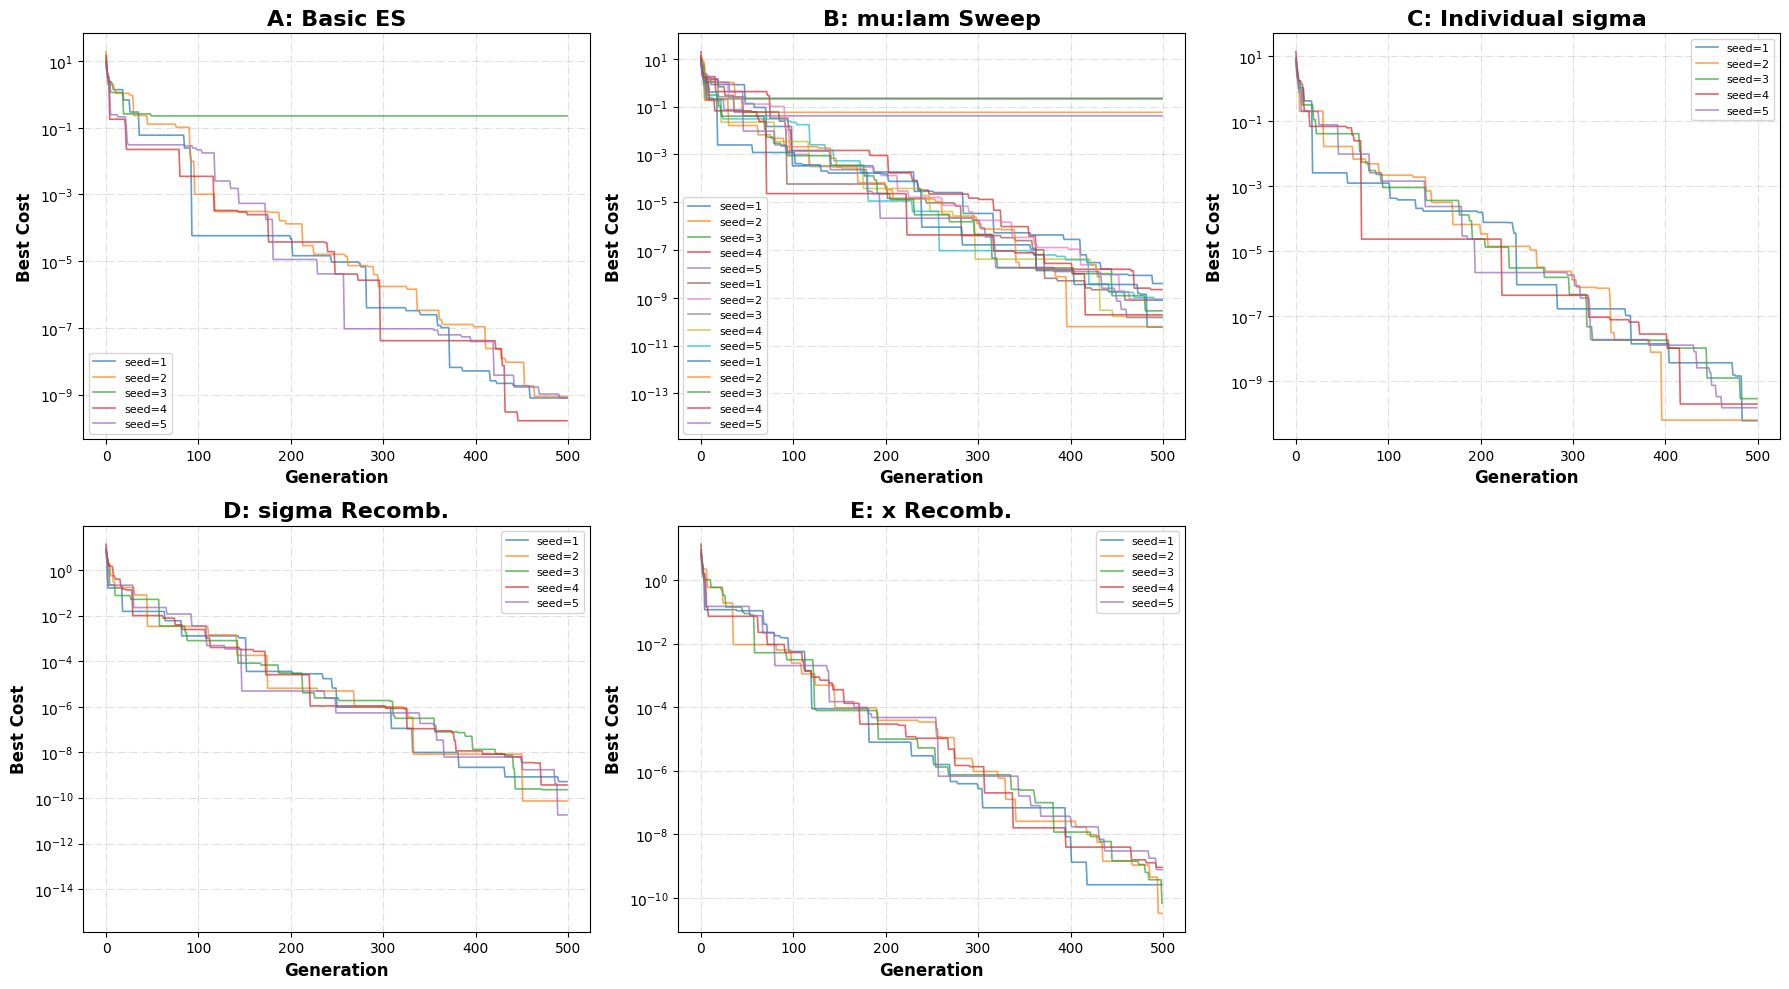

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, exp in enumerate(experiments):
    ax = axes[idx]
    subset = results_df[results_df['experiment'] == exp]
    for _, row in subset.iterrows():
        ax.plot(row['history'], alpha=0.7, linewidth=1.2, label=f"seed={row['seed']}")
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Generation", fontsize=12, fontweight='bold')
    ax.set_ylabel("Best Cost", fontsize=12, fontweight='bold')
    ax.set_yscale('log')

    ax.set_title(exp_labels[exp], fontsize=16, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, linestyle='-.', alpha=0.4)

axes[5].axis('off')  # hide 6th subplot
#plt.suptitle("Convergence Curves for All ES Variants", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ES_Results/convergence_all_experiments.png', dpi=300, bbox_inches='tight')
plt.show()

## 9.3 mu:lam Ratio Analysis (Experiment B)

/var/folders/w2/8rhf6prd1mv2_x48l625r7nw0000gn/T/ipykernel_87119/1739827099.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_r, labels=ratios, patch_artist=True)


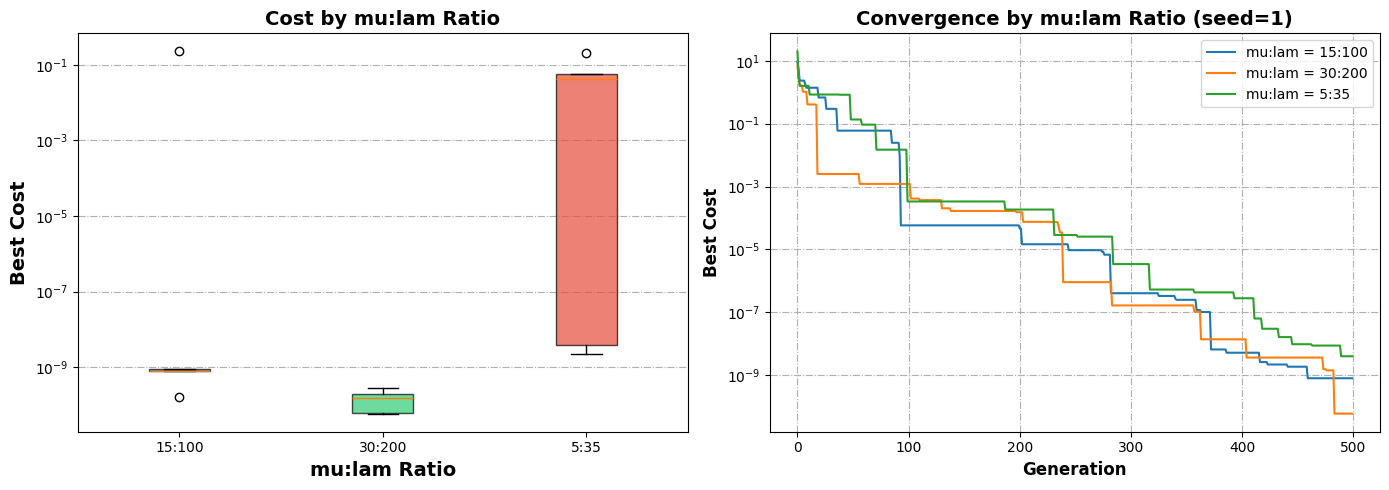

Mean cost by mu:lam ratio:
                      mean           std           min           max
mu_lam_ratio                                                        
15:100        4.538189e-02  1.014770e-01  1.640359e-10  2.269095e-01
30:200        1.497540e-10  9.475213e-11  5.922374e-11  2.841958e-10
5:35          6.239615e-02  8.770827e-02  2.203659e-09  2.124751e-01


In [48]:
df_b = results_df[results_df['experiment'] == 'B_ratio'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot by ratio
ratios = sorted(df_b['mu_lam_ratio'].unique())
data_r = [df_b[df_b['mu_lam_ratio'] == r]['best_cost'].values for r in ratios]
bp = axes[0].boxplot(data_r, labels=ratios, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c']):
    patch.set_facecolor(color); patch.set_alpha(0.7); fontsize = 14
axes[0].set_xlabel("mu:lam Ratio", fontsize=14, fontweight='bold')

axes[0].set_ylabel("Best Cost", fontsize=14, fontweight='bold')
axes[0].set_yscale('log')

axes[0].set_title("Cost by mu:lam Ratio", fontsize=14, fontweight='bold')
axes[0].grid(True, axis='y', linestyle='-.')

# Convergence by ratio (seed=1)
for r in ratios:
    sub = df_b[(df_b['mu_lam_ratio'] == r) & (df_b['seed'] == 1)]
    if len(sub) > 0:
        axes[1].plot(sub.iloc[0]['history'], label=f'mu:lam = {r}', linewidth=1.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_xlabel("Generation",fontsize=12, fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_ylabel("Best Cost", fontsize=12, fontweight='bold')
axes[1].set_title("Convergence by mu:lam Ratio (seed=1)", fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='-.')

plt.tight_layout()
plt.savefig('ES_Results/ratio_analysis.png', dpi=400, bbox_inches='tight')
plt.show()

# Stats
print("Mean cost by mu:lam ratio:")
print(df_b.groupby('mu_lam_ratio')['best_cost'].agg(['mean','std','min','max']))

## 9.4 Best Solution Across All 35 Runs

BEST SOLUTION ACROSS ALL 35 RUNS
  Experiment:  D_sigma_recomb
  Seed:        5
  mu:lam ratio:30:200
  x* = (-0.00000002, 0.00000030)
  f(x*) = 0.00000000
  Runtime: 0.634s


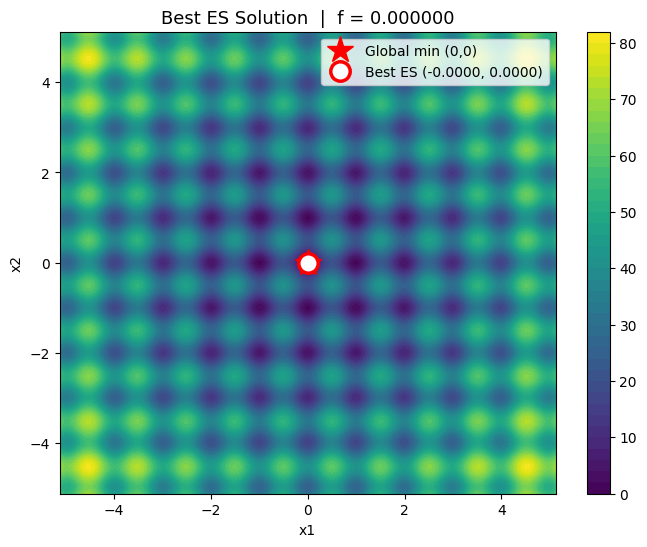

In [17]:
best_overall = results_df.loc[results_df['best_cost'].idxmin()]
print("=" * 50)
print("BEST SOLUTION ACROSS ALL 35 RUNS")
print("=" * 50)
print(f"  Experiment:  {best_overall['experiment']}")
print(f"  Seed:        {best_overall['seed']}")
print(f"  mu:lam ratio:{best_overall['mu_lam_ratio']}")
print(f"  x* = ({best_overall['best_x1']:.8f}, {best_overall['best_x2']:.8f})")
print(f"  f(x*) = {best_overall['best_cost']:.8f}")
print(f"  Runtime: {best_overall['runtime_s']:.3f}s")

# Contour with best solution
fig, ax = plt.subplots(figsize=(8, 6))
c = ax.contourf(X1, X2, Z, levels=50, cmap='viridis')
plt.colorbar(c, ax=ax)
ax.plot(0, 0, 'r*', markersize=20, label='Global min (0,0)', zorder=5)
ax.plot(best_overall['best_x1'], best_overall['best_x2'], 'wo', markersize=14,
        markeredgecolor='red', markeredgewidth=2.5, zorder=5,
        label=f"Best ES ({best_overall['best_x1']:.4f}, {best_overall['best_x2']:.4f})")
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title(f"Best ES Solution  |  f = {best_overall['best_cost']:.6f}", fontsize=13)
ax.legend(loc='upper right')
plt.savefig('ES_Results/best_solution_contour.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.5 One-Way ANOVA: Experiment Effect

In [18]:
groups = [results_df[results_df['experiment'] == e]['best_cost'].values for e in experiments]
F_stat, p_val = f_oneway(*groups)
print(f"One-Way ANOVA across experiments: F = {F_stat:.4f}, p = {p_val:.6e}")
if p_val < 0.05:
    print("-> Statistically significant difference between ES variants (p < 0.05)")
else:
    print("-> No statistically significant difference (p >= 0.05)")

# Pairwise t-tests
print("\nPairwise Welch t-tests:")
for i in range(len(experiments)):
    for j in range(i+1, len(experiments)):
        a = results_df[results_df['experiment'] == experiments[i]]['best_cost'].values
        b = results_df[results_df['experiment'] == experiments[j]]['best_cost'].values
        if len(a) > 1 and len(b) > 1:
            t, p = ttest_ind(a, b, equal_var=False)
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            print(f"  {exp_labels[experiments[i]]} vs {exp_labels[experiments[j]]}: t={t:.3f}, p={p:.4e} {sig}")

One-Way ANOVA across experiments: F = 0.7832, p = 5.450895e-01
-> No statistically significant difference (p >= 0.05)

Pairwise Welch t-tests:
  A: Basic ES vs B: mu:lam Sweep: t=0.191, p=8.5527e-01 ns
  A: Basic ES vs C: Individual sigma: t=1.000, p=3.7390e-01 ns
  A: Basic ES vs D: sigma Recomb.: t=1.000, p=3.7390e-01 ns
  A: Basic ES vs E: x Recomb.: t=1.000, p=3.7390e-01 ns
  B: mu:lam Sweep vs C: Individual sigma: t=1.814, p=9.1156e-02 ns
  B: mu:lam Sweep vs D: sigma Recomb.: t=1.814, p=9.1156e-02 ns
  B: mu:lam Sweep vs E: x Recomb.: t=1.814, p=9.1156e-02 ns
  C: Individual sigma vs D: sigma Recomb.: t=-0.923, p=3.9444e-01 ns
  C: Individual sigma vs E: x Recomb.: t=-1.370, p=2.3489e-01 ns
  D: sigma Recomb. vs E: x Recomb.: t=-0.733, p=4.8969e-01 ns


## 9.6 Stability Analysis & Runtime

Stability by Experiment (mean, std, min, max):
                        mean           std           min           max  count
experiment                                                                   
A_basic         4.538189e-02  1.014770e-01  1.640359e-10  2.269095e-01      5
B_ratio         3.592601e-02  7.670215e-02  5.922374e-11  2.269095e-01     15
C_indiv_sigma   1.497540e-10  9.475213e-11  5.922374e-11  2.841958e-10      5
D_sigma_recomb  2.446235e-10  2.095146e-10  1.812239e-11  5.246719e-10      5
E_var_recomb    3.843873e-10  3.711282e-10  3.313261e-11  7.820944e-10      5

Runtime by Experiment:
                    mean       std       min       max
experiment                                            
A_basic         0.131300  0.002115  0.128681  0.133421
B_ratio         0.141662  0.081454  0.049382  0.242930
C_indiv_sigma   0.238977  0.001370  0.237475  0.240430
D_sigma_recomb  0.635078  0.006089  0.628381  0.644925
E_var_recomb    0.808174  0.006742  0.799309  0.81644

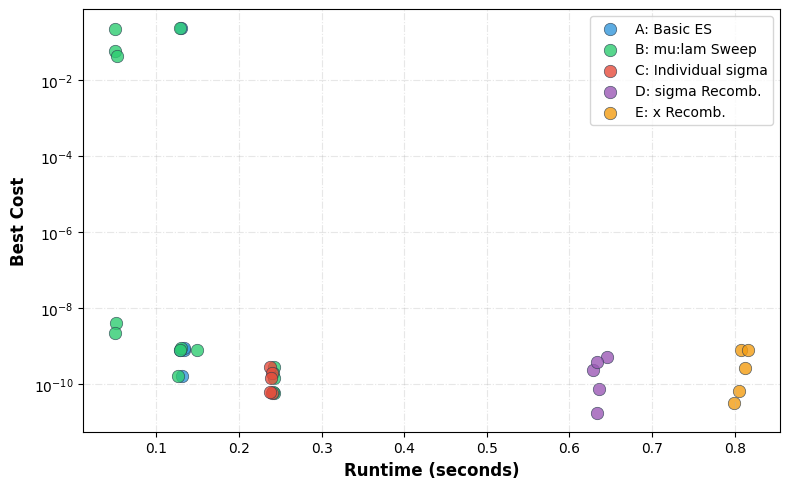

In [53]:
print("Stability by Experiment (mean, std, min, max):")
stability = results_df.groupby('experiment')['best_cost'].agg(['mean','std','min','max','count'])
print(stability)

print("\nRuntime by Experiment:")
rt = results_df.groupby('experiment')['runtime_s'].agg(['mean','std','min','max'])
print(rt)

# Runtime scatter
fig, ax = plt.subplots(figsize=(8, 5))
colors_map = {'A_basic':'#3498db', 'B_ratio':'#2ecc71', 'C_indiv_sigma':'#e74c3c',
              'D_sigma_recomb':'#9b59b6', 'E_var_recomb':'#f39c12'}
for exp in experiments:
    sub = results_df[results_df['experiment'] == exp]
    ax.scatter(sub['runtime_s'], sub['best_cost'], c=colors_map[exp],
               label=exp_labels[exp], s=80, edgecolors='#2c3e50', linewidth=0.5, alpha=0.8)
ax.set_xlabel("Runtime (seconds)", fontsize=12, fontweight='bold')
ax.set_ylabel("Best Cost", fontsize=12, fontweight='bold')
ax.set_yscale('log')
#ax.set_title("Runtime vs Cost Tradeoff", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='both', linestyle='-.')
plt.tight_layout()
plt.savefig('ES_Results/runtime_vs_cost.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 10: Summary Table & Conclusions

In [20]:
summary = pd.DataFrame({
    'Experiment': [exp_labels[e] for e in experiments],
    'Num Runs': [len(results_df[results_df['experiment']==e]) for e in experiments],
    'Mean Cost': [results_df[results_df['experiment']==e]['best_cost'].mean() for e in experiments],
    'Std': [results_df[results_df['experiment']==e]['best_cost'].std() for e in experiments],
    'Min Cost': [results_df[results_df['experiment']==e]['best_cost'].min() for e in experiments],
    'Max Cost': [results_df[results_df['experiment']==e]['best_cost'].max() for e in experiments],
    'Mean Runtime (s)': [results_df[results_df['experiment']==e]['runtime_s'].mean() for e in experiments],
})
print("\n" + "="*70)
print("SUMMARY TABLE - ALL EXPERIMENTS")
print("="*70)
display(summary)

print(f"\nTotal runs: {len(results_df)} (expected: 35)")

best = results_df.loc[results_df['best_cost'].idxmin()]
print(f"\nOverall best: Experiment {best['experiment']}, seed={best['seed']},")
print(f"  mu:lam = {best['mu_lam_ratio']},  f* = {best['best_cost']:.8f}")
print(f"  x* = ({best['best_x1']:.8f}, {best['best_x2']:.8f})")

summary.to_csv('ES_Results/summary_table.csv', index=False)
print("\nAll results saved to ES_Results/")


SUMMARY TABLE - ALL EXPERIMENTS


,Experiment,Num Runs,Mean Cost,Std,Min Cost,Max Cost,Mean Runtime (s)
0,A: Basic ES,5,4.538189e-02,1.014770e-01,1.640359e-10,2.269095e-01,0.131300
1,B: mu:lam Sweep,15,3.592601e-02,7.670215e-02,5.922374e-11,2.269095e-01,0.141662
2,C: Individual sigma,5,1.497540e-10,9.475213e-11,5.922374e-11,2.841958e-10,0.238977
3,D: sigma Recomb.,5,2.446235e-10,2.095146e-10,1.812239e-11,5.246719e-10,0.635078
4,E: x Recomb.,5,3.843873e-10,3.711282e-10,3.313261e-11,7.820944e-10,0.808174



Total runs: 35 (expected: 35)

Overall best: Experiment D_sigma_recomb, seed=5,
  mu:lam = 30:200,  f* = 0.00000000
  x* = (-0.00000002, 0.00000030)

All results saved to ES_Results/
